<a href="https://colab.research.google.com/github/IPutuArcana/MachineLearningTask1_UNDIKSHA/blob/main/Polynomial_Regression(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


.txt to .csv

In [ ]:
import pandas as pd

# 1. Define the original 26 column names
columns = ['Engine', 'Cycle', 'OpSet1', 'OpSet2', 'OpSet3'] + [f'Sensor{i}' for i in range(1, 22)]

# 2. Load the original text dataset from your Drive
# (Using the raw string 'r' to avoid the warning!)
file_path = '/content/drive/MyDrive/NASATJE/train_FD001.txt'
df = pd.read_csv(file_path, sep=r'\s+', header=None, names=columns)

# 3. Calculate RUL (Your Target Variable Y)
max_cycles = df.groupby('Engine')['Cycle'].max()
df['RUL'] = df.apply(lambda row: max_cycles[row['Engine']] - row['Cycle'], axis=1)

# 4. Create a new table (DataFrame) with ONLY the columns you are using
# For this example, we used Sensor 2, Sensor 3, and Sensor 4
df_clean = df[['Sensor2', 'Sensor3', 'Sensor4', 'RUL']].copy()

# 5. Rename the columns to X1, X2, X3, and Y
df_clean.columns = ['X1', 'X2', 'X3', 'Y']

# 6. Save this clean table as a new CSV file in your Google Drive
# We use index=False so pandas doesn't write the row numbers (0, 1, 2...) into the file
save_path = '/content/drive/MyDrive/NASATJE/dataset_skripsi_clean.csv'
df_clean.to_csv(save_path, index=False)

print(f"Success! Clean CSV file saved to: {save_path}\n")

# Display the first 5 rows to show you what the new table looks like
print("Here is a preview of your new dataset:")
print(df_clean.head())

Success! Clean CSV file saved to: /content/drive/MyDrive/NASATJE/dataset_skripsi_clean.csv

Here is a preview of your new dataset:
       X1       X2       X3      Y
0  641.82  1589.70  1400.60  191.0
1  642.15  1591.82  1403.14  190.0
2  642.35  1587.99  1404.20  189.0
3  642.35  1582.79  1401.87  188.0
4  642.37  1582.85  1406.22  187.0


# **FINAL with Matrix (POLYNOMIAL REGRESSION)**

In [5]:
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement

# Suppress scientific notation (e.g., 1.5e-4) so the matrices look clean for your thesis
np.set_printoptions(suppress=True, precision=4)

# ==========================================
# 1. CORE FUNCTIONS
# ==========================================

def build_polynomial_matrix(X_data, order):
    n_samples, n_features = X_data.shape
    poly_features = [np.ones(n_samples)]
    feature_names = ["Intercept"]

    for d in range(1, order + 1):
        for combo in combinations_with_replacement(range(n_features), d):
            new_feature = np.prod(X_data[:, combo], axis=1)
            poly_features.append(new_feature)
            name = "*".join([f"X{idx + 1}" for idx in combo])
            feature_names.append(name)

    Matrix_X = np.column_stack(poly_features)
    return Matrix_X, feature_names

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def calculate_r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def calculate_bic(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    bic = n * np.log(rss / n) + k * np.log(n)
    return bic

# Custom function to print matrices with "..." for explanation
def print_truncated_matrix(name, matrix):
    rows, cols = matrix.shape
    print(f"\n--- {name} ({rows}x{cols}) ---")

    # Helper function to format a single row (Truncates columns if > 6)
    def format_row(row_array):
        if cols > 6:
            # Print first 3 columns, then ..., then the last column
            first_cols = "  ".join([f"{x:12.4f}" for x in row_array[:3]])
            last_col = f"{row_array[-1]:12.4f}"
            return f"{first_cols}      ...       {last_col}"
        else:
            # Print all columns normally
            return "  ".join([f"{x:12.4f}" for x in row_array])

    # Truncate rows if > 10
    if rows > 10:
        for r in range(3):
            print("  [" + format_row(matrix[r]) + "]")

        # Print vertical dots depending on how wide the matrix is
        if cols > 6:
            print("  [         ...           ...           ...      ...                ... ]")
        else:
            print("  [" + "  ".join(["         ..."] * cols) + "]")

        print("  [" + format_row(matrix[-1]) + "]")

    # If rows are <= 10, just print them (but columns will still truncate if needed!)
    else:
        for r in range(rows):
            print("  [" + format_row(matrix[r]) + "]")


# ==========================================
# 2. DATA PREPARATION
# ==========================================

print("Loading dataset...")
file_path = '/content/drive/MyDrive/NASATJE/train_FD001.txt'
columns = ['Engine', 'Cycle', 'OpSet1', 'OpSet2', 'OpSet3'] + [f'Sensor{i}' for i in range(1, 22)]

try:
    df = pd.read_csv(file_path, sep=r'\s+', header=None, names=columns)
except FileNotFoundError:
    print("Error: File not found.")
    exit()

max_cycles = df.groupby('Engine')['Cycle'].max()
df['RUL'] = df.apply(lambda row: max_cycles[row['Engine']] - row['Cycle'], axis=1)

X_raw = df[['Sensor2', 'Sensor3', 'Sensor4']].values
y_true = df['RUL'].values

# ==========================================
# 3. PHASE 1: AUTOMATED ORDER TESTING
# ==========================================

print("\n" + "="*50)
print("PHASE 1: FINDING THE BEST MODEL (LOWEST BIC)")
print("="*50)

best_order = 0
lowest_bic = float('inf') # Start with an infinitely high score

for current_order in range(1, 4):
    print(f"\nEvaluating Order {current_order}...")
    X, feature_names = build_polynomial_matrix(X_raw, order=current_order)
    k = len(feature_names)

    X_T_X = X.T.dot(X)

    try:
        X_T_X_inv = np.linalg.inv(X_T_X)
    except np.linalg.LinAlgError:
        print(f" -> ERROR: Singular Matrix. Order {current_order} failed.")
        continue

    beta = X_T_X_inv.dot(X.T.dot(y_true))
    y_pred = X.dot(beta)

    bic_score = calculate_bic(y_true, y_pred, k)
    print(f" -> BIC Score: {bic_score:.2f}")

    # Check if this is the best score we've seen so far
    if bic_score < lowest_bic:
        lowest_bic = bic_score
        best_order = current_order

print(f"\n*** THE WINNER IS ORDER {best_order} ***")

# ==========================================
# 4. PHASE 2: PRINT MATRICES
# ==========================================

print("\n" + "="*50)
print(f"PHASE 2: GENERATING MATRIX OUTPUT FOR ORDER {best_order}")
print("="*50)

# Rebuild the optimal matrix
X_opt, optimal_features = build_polynomial_matrix(X_raw, order=best_order)

# 1. Print X and y
print_truncated_matrix("Design Matrix X", X_opt)
print_truncated_matrix("Target Vector y", y_true.reshape(-1, 1))

#d. Print X transpose
print_truncated_matrix("X^T", X_opt.T)

# 2. X Transpose multiplied by X
X_T_opt = X_opt.T
X_T_X_opt = X_T_opt.dot(X_opt)
print_truncated_matrix("X^T multiplied by X", X_T_X_opt)

# 3. Inverse of (X^T X)
X_T_X_inv_opt = np.linalg.inv(X_T_X_opt)
print_truncated_matrix("Inverse (X^T X)^-1", X_T_X_inv_opt)

# 4. X Transpose multiplied by y
X_T_y_opt = X_T_opt.dot(y_true)
print_truncated_matrix("X^T multiplied by y", X_T_y_opt.reshape(-1, 1))

# 5. Final Beta Coefficients
beta_opt = X_T_X_inv_opt.dot(X_T_y_opt)
print_truncated_matrix("Final Coefficients (Beta)", beta_opt.reshape(-1, 1))

print("\n--- COEFFICIENT MAPPING ---")
for name, coef in zip(optimal_features, beta_opt):
    print(f"{name:15}: {coef:.4f}")

# ==========================================
# 5. PRINT FINAL MATHEMATICAL EQUATION
# ==========================================
print("\n" + "="*50)
print("FINAL MATHEMATICAL EQUATION")
print("="*50)

# Start the equation with the Intercept (Beta 0)
equation_parts = [f"{beta_opt[0]:.4f}"]

# Loop through the rest of the coefficients
for name, coef in zip(optimal_features[1:], beta_opt[1:]):
    # If the number is positive, add a plus sign. If negative, add a minus sign.
    if coef >= 0:
        equation_parts.append(f"+ {coef:.4f}({name})")
    else:
        # We use abs() to remove the negative sign from the number itself since we typed "-"
        equation_parts.append(f"- {abs(coef):.4f}({name})")

# Join everything together into one readable string
final_equation = "Y = " + " ".join(equation_parts)

print(final_equation)
print("="*50)

Loading dataset...

PHASE 1: FINDING THE BEST MODEL (LOWEST BIC)

Evaluating Order 1...
 -> BIC Score: 160020.15

Evaluating Order 2...
 -> BIC Score: 160073.30

Evaluating Order 3...
 -> BIC Score: 246520.82

*** THE WINNER IS ORDER 1 ***

PHASE 2: GENERATING MATRIX OUTPUT FOR ORDER 1

--- Design Matrix X (20631x4) ---
  [      1.0000      641.8200     1589.7000     1400.6000]
  [      1.0000      642.1500     1591.8200     1403.1400]
  [      1.0000      642.3500     1587.9900     1404.2000]
  [         ...           ...           ...           ...]
  [      1.0000      643.8500     1600.3800     1432.1400]

--- Target Vector y (20631x1) ---
  [    191.0000]
  [    190.0000]
  [    189.0000]
  [         ...]
  [      0.0000]

--- X^T (4x20631) ---
  [      1.0000        1.0000        1.0000      ...             1.0000]
  [    641.8200      642.1500      642.3500      ...           643.8500]
  [   1589.7000     1591.8200     1587.9900      ...          1600.3800]
  [   1400.6000     1

# **Orde 2**

In [6]:
# ==========================================
# 4. PHASE 2: PRINT MATRICES FOR ORDER 2 (TUGAS)
# ==========================================
TARGET_ORDER = 2 # Memaksa output untuk Orde 2 sesuai permintaan tugas

print("\n" + "="*50)
print(f"PHASE 2: GENERATING MATRIX OUTPUT FOR ORDER {TARGET_ORDER} (TUGAS REQUIREMENT)")
print("="*50)

# Rebuild the optimal matrix specifically for Order 2
X_opt, optimal_features = build_polynomial_matrix(X_raw, order=TARGET_ORDER)

# 1. Print X and y
print_truncated_matrix("Design Matrix X", X_opt)
print_truncated_matrix("Target Vector y", y_true.reshape(-1, 1))

# 2. Print X transpose
print_truncated_matrix("X^T", X_opt.T)

# 3. X Transpose multiplied by X
X_T_opt = X_opt.T
X_T_X_opt = X_T_opt.dot(X_opt)
print_truncated_matrix("X^T multiplied by X", X_T_X_opt)

# 4. Inverse of (X^T X)
X_T_X_inv_opt = np.linalg.inv(X_T_X_opt)
print_truncated_matrix("Inverse (X^T X)^-1", X_T_X_inv_opt)

# 5. X Transpose multiplied by y
X_T_y_opt = X_T_opt.dot(y_true)
print_truncated_matrix("X^T multiplied by y", X_T_y_opt.reshape(-1, 1))

# 6. Final Beta Coefficients
beta_opt = X_T_X_inv_opt.dot(X_T_y_opt)
print_truncated_matrix("Final Coefficients (Beta)", beta_opt.reshape(-1, 1))

print("\n--- COEFFICIENT MAPPING ---")
for name, coef in zip(optimal_features, beta_opt):
    print(f"{name:15}: {coef:.4f}")

# ==========================================
# 5. PRINT FINAL MATHEMATICAL EQUATION
# ==========================================
print("\n" + "="*50)
print(f"FINAL MATHEMATICAL EQUATION (ORDER {TARGET_ORDER})")
print("="*50)

# Start the equation with the Intercept (Beta 0)
equation_parts = [f"{beta_opt[0]:.4f}"]

# Loop through the rest of the coefficients
for name, coef in zip(optimal_features[1:], beta_opt[1:]):
    # If the number is positive, add a plus sign. If negative, add a minus sign.
    if coef >= 0:
        equation_parts.append(f"+ {coef:.4f}({name})")
    else:
        # We use abs() to remove the negative sign from the number itself since we typed "-"
        equation_parts.append(f"- {abs(coef):.4f}({name})")

# Join everything together into one readable string
final_equation = "Y = " + " ".join(equation_parts)

print(final_equation)
print("="*50)


PHASE 2: GENERATING MATRIX OUTPUT FOR ORDER 2 (TUGAS REQUIREMENT)

--- Design Matrix X (20631x10) ---
  [      1.0000      641.8200     1589.7000      ...       1961680.3600]
  [      1.0000      642.1500     1591.8200      ...       1968801.8596]
  [      1.0000      642.3500     1587.9900      ...       1971777.6400]
  [         ...           ...           ...      ...                ... ]
  [      1.0000      643.8500     1600.3800      ...       2051024.9796]

--- Target Vector y (20631x1) ---
  [    191.0000]
  [    190.0000]
  [    189.0000]
  [         ...]
  [      0.0000]

--- X^T (10x20631) ---
  [      1.0000        1.0000        1.0000      ...             1.0000]
  [    641.8200      642.1500      642.3500      ...           643.8500]
  [   1589.7000     1591.8200     1587.9900      ...          1600.3800]
  [   1400.6000     1403.1400     1404.2000      ...          1432.1400]
  [ 411932.9124   412356.6225   412613.5225      ...        414542.8225]
  [1020301.2540  10221

# **K-NN (Breast Cancer)**

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

# ==========================================
# 1. DISTANCE FORMULAS (PERHITUNGAN JARAK)
# ==========================================
def calculate_distance(point1, point2, metric='euclidean'):
    if metric == 'euclidean':
        # Akar dari jumlah kuadrat selisih
        return np.sqrt(np.sum((point1 - point2)**2))
    elif metric == 'manhattan':
        # Jumlah nilai absolut selisih
        return np.sum(np.abs(point1 - point2))

# ==========================================
# 2. KNN ALGORITHM DARI AWAL
# ==========================================
def knn_predict(X_train, y_train, X_test_point, k=5, metric='euclidean'):
    distances = []

    # Hitung jarak dari data test ke SEMUA data train
    for i in range(len(X_train)):
        dist = calculate_distance(X_test_point, X_train[i], metric=metric)
        distances.append((dist, y_train[i]))

    # Urutkan jarak dari yang terdekat
    distances.sort(key=lambda x: x[0])

    # Ambil K tetangga terdekat
    k_nearest_labels = [label for _, label in distances[:k]]

    # Voting terbanyak (Mayoritas)
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

def evaluate_knn(X_train, y_train, X_test, y_test, k=5, metric='euclidean'):
    predictions = []
    for point in X_test:
        pred = knn_predict(X_train, y_train, point, k, metric)
        predictions.append(pred)

    # Hitung akurasi
    correct = np.sum(predictions == y_test)
    accuracy = (correct / len(y_test)) * 100
    return accuracy, predictions

# ==========================================
# 3. DATA PREPARATION & PREPROCESSING
# ==========================================
print("Loading Breast Cancer Dataset...")
# Ganti path ini sesuai dengan lokasi file CSV di Google Drive kamu
file_path = '/content/drive/MyDrive/NASATJE/BCdata.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("Error: File not found. Please upload 'data.csv' to your path.")
    exit()

# Bersihkan data: Hapus kolom ID dan kolom kosong di akhir (Unnamed: 32)
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Ubah Target (Diagnosis) menjadi angka: Malignant (M) = 1, Benign (B) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X_raw = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

# Min-Max Scaling dari awal (Ubah semua nilai menjadi range 0 sampai 1)
print("Scaling Data...")
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

# Shuffle (Acak) data agar distribusi train dan test adil
np.random.seed(42) # Seed agar hasil acakan selalu sama setiap kali di-run
indices = np.random.permutation(len(X_scaled))
X_shuffled = X_scaled[indices]
y_shuffled = y[indices]

# Split Data: 80% Training, 20% Testing
split_index = int(0.8 * len(X_shuffled))
X_train, X_test = X_shuffled[:split_index], X_shuffled[split_index:]
y_train, y_test = y_shuffled[:split_index], y_shuffled[split_index:]

print(f"Data split selesai: {len(X_train)} Train, {len(X_test)} Test.\n")

# ==========================================
# 4. RUNNING THE MODEL & OUTPUT EVALUATION
# ==========================================
K_VALUE = 5

print("="*50)
print(f"EVALUASI MODEL KNN (K = {K_VALUE})")
print("="*50)

# Uji menggunakan Jarak Euclidean
print("1. Menggunakan Perhitungan Jarak Euclidean...")
acc_euclidean, preds_euclidean = evaluate_knn(X_train, y_train, X_test, y_test, k=K_VALUE, metric='euclidean')
print(f"   -> Akurasi Euclidean: {acc_euclidean:.2f}%\n")

# Uji menggunakan Jarak Manhattan
print("2. Menggunakan Perhitungan Jarak Manhattan...")
acc_manhattan, preds_manhattan = evaluate_knn(X_train, y_train, X_test, y_test, k=K_VALUE, metric='manhattan')
print(f"   -> Akurasi Manhattan: {acc_manhattan:.2f}%\n")

print("="*50)
print("KESIMPULAN:")
if acc_euclidean > acc_manhattan:
    print("Jarak Euclidean memberikan akurasi yang lebih tinggi pada dataset ini.")
elif acc_manhattan > acc_euclidean:
    print("Jarak Manhattan memberikan akurasi yang lebih tinggi pada dataset ini.")
else:
    print("Kedua perhitungan jarak memberikan akurasi yang sama.")
print("="*50)

Loading Breast Cancer Dataset...
Scaling Data...
Data split selesai: 455 Train, 114 Test.

EVALUASI MODEL KNN (K = 5)
1. Menggunakan Perhitungan Jarak Euclidean...
   -> Akurasi Euclidean: 93.86%

2. Menggunakan Perhitungan Jarak Manhattan...
   -> Akurasi Manhattan: 94.74%

KESIMPULAN:
Jarak Manhattan memberikan akurasi yang lebih tinggi pada dataset ini.


Membaca dataset Breast Cancer...

**************************************************
PROGRAM K-NEAREST NEIGHBORS (K-NN)
**************************************************
1. Lihat Detail Rumus (FULL 30 FITUR) Berdasarkan ID
2. Klasifikasikan Data Pasien Baru & Tampilkan Grafik
3. Keluar dari Program

Masukkan pilihan Anda (1/2/3): 2

Menyiapkan Data Pasien Baru (Randomized)...

TABEL: DATA PASIEN BARU (X_baru)
 X1 :  17.83   |   X2 :  16.61   |   X3 : 127.91
 X4 : 2178.35   |   X5 :   0.15   |   X6 :   0.10
 X7 :   0.39   |   X8 :   0.12   |   X9 :   0.18
 X10:   0.08   |   X11:   1.44   |   X12:   2.07
 X13:  15.72   |   X14: 139.97   |   X15:   0.01
 X16:   0.06   |   X17:   0.10   |   X18:   0.02
 X19:   0.05   |   X20:   0.02   |   X21:  29.50
 X22:  42.89   |   X23: 199.84   |   X24: 2956.21
 X25:   0.11   |   X26:   0.44   |   X27:   0.60
 X28:   0.02   |   X29:   0.42   |   X30:   0.12

Menjalankan Prediksi KNN (K=5) pada Data Pasien Baru tersebut...

--> Menurut EUCLIDEAN, Data

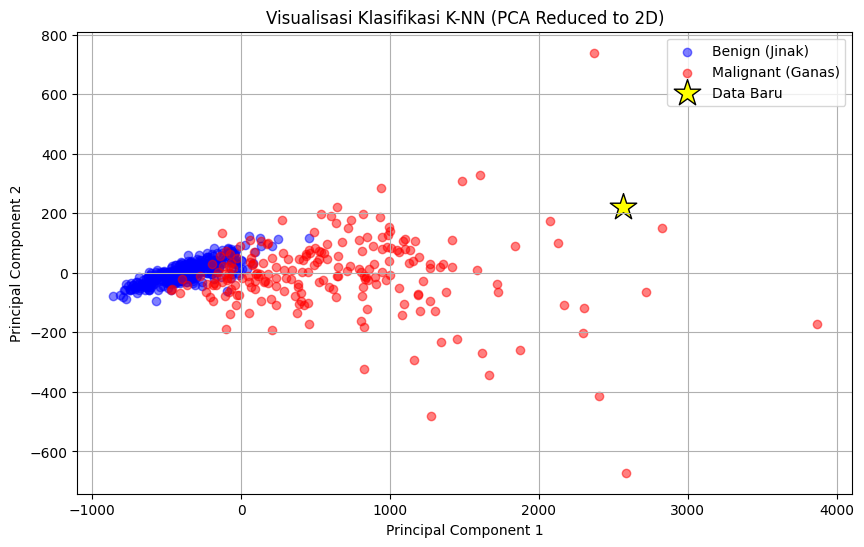


**************************************************
PROGRAM K-NEAREST NEIGHBORS (K-NN)
**************************************************
1. Lihat Detail Rumus (FULL 30 FITUR) Berdasarkan ID
2. Klasifikasikan Data Pasien Baru & Tampilkan Grafik
3. Keluar dari Program


KeyboardInterrupt: Interrupted by user

In [10]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # Hanya digunakan untuk plotting visual 2D


# ==========================================
# 1. PERSIAPAN DATA
# ==========================================
print("Membaca dataset Breast Cancer...")
file_path = '/content/drive/MyDrive/NASATJE/BCdata.csv'

try:
    df = pd.read_csv(file_path).drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

    X_matrix = df.drop('diagnosis', axis=1).values
    y_labels = df['diagnosis'].values
except FileNotFoundError:
    print("Error: File data.csv tidak ditemukan.")
    exit()

# Kita buat satu "Data Baru" (Misal: pasien baru dengan nilai fitur tertentu)
# Di sini kita ambil rata-rata dataset, lalu kita kurangi sedikit agar tidak persis sama
X_baru = np.mean(X_matrix, axis=0) * 0.9

# ==========================================
# 2. FUNGSI INTI K-NN & MATEMATIKA FULL
# ==========================================
def calculate_distance(point1, point2, metric='euclidean'):
    if metric == 'euclidean':
        return np.sqrt(np.sum((point1 - point2)**2))
    elif metric == 'manhattan':
        return np.sum(np.abs(point1 - point2))

def knn_predict(X_train, y_train, X_test_point, k=5, metric='euclidean'):
    distances = []
    for i in range(len(X_train)):
        dist = calculate_distance(X_test_point, X_train[i], metric=metric)
        distances.append((dist, y_train[i], i)) # Simpan index (i) juga

    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]
    k_nearest_labels = [label for _, label, _ in k_nearest]
    most_common = Counter(k_nearest_labels).most_common(1)

    # Return hasil voting, tetangga terdekat, dan index data paling dekat
    return most_common[0][0], k_nearest, distances[0][2]

def print_full_math_for_row(row_id, data_pembanding):
    x_data = X_matrix[row_id]

    print("\n" + "="*90)
    print(f"DETAIL PERHITUNGAN FULL 30 FITUR (DATA ID: {row_id} vs DATA BARU)")
    print("="*90)

    diffs = x_data - data_pembanding
    sqs = diffs ** 2
    sum_sq = np.sum(sqs)
    dist_euc = np.sqrt(sum_sq)

    # 1. Membuat string EUCLIDEAN FULL (tanpa ...)
    print("[1] JARAK EUCLIDEAN:")
    step1_parts = [f"({x_data[i]:.2f} - {data_pembanding[i]:.2f})²" for i in range(len(x_data))]
    step1_str = " + ".join(step1_parts)

    step2_parts = [f"{sqs[i]:.2f}" for i in range(len(sqs))]
    step2_str = " + ".join(step2_parts)

    print(f"Subtitusi : √({step1_str})")
    print(f"Kuadrat   : √({step2_str})")
    print(f"Hasil     : √{sum_sq:.2f} = {dist_euc:.2f}")

    # 2. Membuat string MANHATTAN FULL (tanpa ...)
    print("\n[2] JARAK MANHATTAN:")
    abs_vals = np.abs(diffs)
    dist_man = np.sum(abs_vals)

    m_step1_parts = [f"|{x_data[i]:.2f} - {data_pembanding[i]:.2f}|" for i in range(len(x_data))]
    m_step1_str = " + ".join(m_step1_parts)

    m_step2_parts = [f"{abs_vals[i]:.2f}" for i in range(len(abs_vals))]
    m_step2_str = " + ".join(m_step2_parts)

    print(f"Subtitusi : {m_step1_str}")
    print(f"Absolut   : {m_step2_str}")
    print(f"Hasil     : {dist_man:.2f}")
    print("="*90)

# ==========================================
# 3. FUNGSI PLOTTING GRAFIK VISUAL (PCA)
# ==========================================
def show_classification_graph(X_train, y_train, X_new, k_nearest_indices):
    print("\nMembuat Grafik Visualisasi 2D...")

    # PCA squishes 30 features into 2 features for X and Y axis mapping
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train)
    X_new_pca = pca.transform([X_new])

    plt.figure(figsize=(10, 6))

    # Plot data Benign (Jinak) = Biru
    plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1], c='blue', label='Benign (Jinak)', alpha=0.5)
    # Plot data Malignant (Ganas) = Merah
    plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], c='red', label='Malignant (Ganas)', alpha=0.5)

    # Plot Data Baru = Bintang Kuning Besar
    plt.scatter(X_new_pca[:, 0], X_new_pca[:, 1], c='yellow', marker='*', s=400, edgecolors='black', label='Data Baru')

    plt.title("Visualisasi Klasifikasi K-NN (PCA Reduced to 2D)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 4. FUNGSI UNTUK MENCETAK TABEL PASIEN BARU
# ==========================================
def print_new_data_table(new_data):
    print("\n" + "="*60)
    print("TABEL: DATA PASIEN BARU (X_baru)")
    print("="*60)

    # Cetak 30 fitur dalam format 3 kolom agar rapi
    for i in range(0, 30, 3):
        col1 = f"X{i+1:<2}: {new_data[i]:>6.2f}"
        col2 = f"X{i+2:<2}: {new_data[i+1]:>6.2f}" if i+1 < 30 else ""
        col3 = f"X{i+3:<2}: {new_data[i+2]:>6.2f}" if i+2 < 30 else ""
        print(f" {col1}   |   {col2}   |   {col3}")
    print("="*60)

# ==========================================
# 5. MENU INTERAKTIF
# ==========================================
while True:
    print("\n" + "*"*50)
    print("PROGRAM K-NEAREST NEIGHBORS (K-NN)")
    print("*"*50)
    print("1. Lihat Detail Rumus (FULL 30 FITUR) Berdasarkan ID")
    print("2. Klasifikasikan Data Pasien Baru & Tampilkan Grafik")
    print("3. Keluar dari Program")

    pilihan = input("\nMasukkan pilihan Anda (1/2/3): ")

    if pilihan == '1':
        try:
            input_id = int(input(f"Masukkan ID Baris Data (0 - {len(X_matrix)-1}): "))
            print_full_math_for_row(input_id, X_baru)
        except ValueError:
            print("Harap masukkan angka yang valid!")

    elif pilihan == '2':
        k_val = 5
        print(f"\nMenyiapkan Data Pasien Baru (Randomized)...")

        # 1. GENERATE RANDOM PATIENT
        # Kita ambil nilai minimum dan maksimum dari setiap fitur, lalu acak angka di antaranya
        X_min = np.min(X_matrix, axis=0)
        X_max = np.max(X_matrix, axis=0)
        X_baru = np.random.uniform(X_min, X_max)

        # 2. Tampilkan tabel nilai X1 sampai X30
        print_new_data_table(X_baru)

        print(f"\nMenjalankan Prediksi KNN (K={k_val}) pada Data Pasien Baru tersebut...")

        # 3. Jalankan prediksi Euclidean
        pred_euc, tetangga_euc, id_terdekat = knn_predict(X_matrix, y_labels, X_baru, k=k_val, metric='euclidean')
        hasil_euc = "Ganas (Malignant)" if pred_euc == 1 else "Jinak (Benign)"

        print(f"\n--> Menurut EUCLIDEAN, Data Baru diklasifikasikan sebagai: {hasil_euc}")
        print("Membuktikan perhitungan dengan tetangga TERDEKAT (ID {}):".format(id_terdekat))

        # 4. Panggil fungsi cetak rumus full untuk membuktikan
        print_full_math_for_row(id_terdekat, X_baru)

        # 5. Tampilkan Grafik (Dioptimalkan untuk Google Colab)
        k_indices = [idx for _, _, idx in tetangga_euc]

        print("\nMenampilkan Grafik Visualisasi 2D...")
        # Matplotlib akan menggambar grafik di output cell Colab
        show_classification_graph(X_matrix, y_labels, X_baru, k_indices)

    elif pilihan == '3':
        print("Program Selesai. Terima kasih!")
        break

    else:
        print("Pilihan tidak dikenali. Silakan coba lagi.")

# **SVM (Linear and Radial Base Function(RBF))**

Membaca dataset Breast Cancer...
Melatih Model SVM Linear dari awal...
Melatih Model SVM RBF dari awal...

**************************************************
PROGRAM SVM DARI AWAL (FROM SCRATCH)
**************************************************
1. Lihat Detail Rumus Kernel (Linear & RBF) Berdasarkan ID
2. Klasifikasikan Pasien Baru & Tampilkan Grafik
3. Keluar

Masukkan pilihan Anda (1/2/3): 2

Menyiapkan Data Pasien Baru (Randomized)...

TABEL: DATA PASIEN BARU (NORMALIZED 0-1)
 X1 :  0.18   |   X2 :  0.61   |   X3 :  0.73
 X4 :  0.96   |   X5 :  0.85   |   X6 :  0.68
 X7 :  0.91   |   X8 :  0.91   |   X9 :  0.99
 X10:  0.66   |   X11:  0.41   |   X12:  0.88
 X13:  0.01   |   X14:  0.46   |   X15:  0.06
 X16:  0.07   |   X17:  0.35   |   X18:  0.27
 X19:  0.75   |   X20:  0.38   |   X21:  0.43
 X22:  0.59   |   X23:  0.66   |   X24:  0.88
 X25:  0.23   |   X26:  0.05   |   X27:  0.19
 X28:  0.96   |   X29:  0.25   |   X30:  0.54

=== HASIL KLASIFIKASI SVM DARI AWAL ===
--> Menurut SV

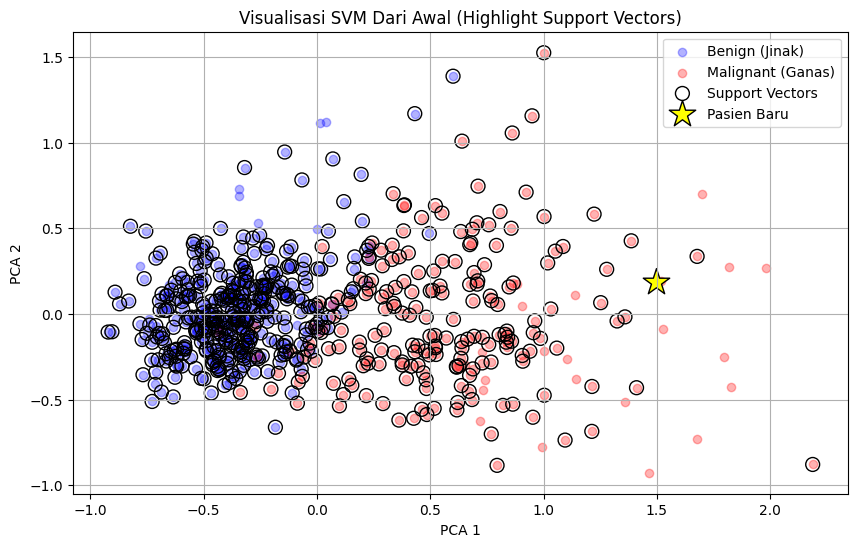


**************************************************
PROGRAM SVM DARI AWAL (FROM SCRATCH)
**************************************************
1. Lihat Detail Rumus Kernel (Linear & RBF) Berdasarkan ID
2. Klasifikasikan Pasien Baru & Tampilkan Grafik
3. Keluar


KeyboardInterrupt: Interrupted by user

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # HANYA untuk menggambar visual 2D
from IPython.display import clear_output

# ==========================================
# 1. PERSIAPAN & NORMALISASI DATA (DARI AWAL)
# ==========================================
print("Membaca dataset Breast Cancer...")
file_path = '/content/drive/MyDrive/NASATJE/BCdata.csv'

try:
    df = pd.read_csv(file_path).drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
    X_raw = df.drop('diagnosis', axis=1).values
    y_labels = df['diagnosis'].values
except FileNotFoundError:
    print("Error: File data.csv tidak ditemukan.")
    exit()

# NORMALISASI MIN-MAX DARI AWAL (Tanpa scikit-learn)
# Rumus: X_scaled = (X - X_min) / (X_max - X_min)
X_min = np.min(X_raw, axis=0)
X_max = np.max(X_raw, axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

# Data Pasien Baru Dummy
X_baru = np.mean(X_scaled, axis=0) * 0.9

# ==========================================
# 2. KELAS SVM DARI AWAL (ALGORITMA PEGASOS / SGD)
# ==========================================
class SVM_Dari_Awal:
    def __init__(self, kernel='linear', epochs=100, lr=0.01, gamma=1.0):
        self.kernel = kernel
        self.epochs = epochs
        self.lr = lr
        self.gamma = gamma
        self.alpha = None
        self.X_train = None
        self.y_train = None
        self.sv_indices = []

    # BEBERAPA PERHITUNGAN JARAK (Sesuai Syarat Tugas)
    def compute_kernel(self, x1, x2):
        if self.kernel == 'linear':
            return np.dot(x1, x2) # Dot Product
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.sum((x1 - x2)**2)) # Euclidean Exponential

    def fit(self, X, y):
        self.X_train = X
        # SVM butuh label -1 dan 1 (Bukan 0 dan 1) untuk hitung Hinge Loss
        self.y_train = np.where(y <= 0, -1, 1)
        n_samples = X.shape[0]
        self.alpha = np.zeros(n_samples)

        # Precompute Kernel Matrix (Agar training sangat cepat)
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = self.compute_kernel(X[i], X[j])

        # Training Loop (Stochastic Gradient Descent pada Hinge Loss)
        for _ in range(self.epochs):
            for i in range(n_samples):
                # Prediksi: jumlah dari (alpha * y * kernel)
                pred = np.sum(self.alpha * self.y_train * K[:, i])

                # Jika margin salah (Hinge Loss), update bobot alpha
                if self.y_train[i] * pred < 1:
                    self.alpha[i] += self.lr

        # Ambil index data yang menjadi Support Vectors (Dimana alpha > 0)
        self.sv_indices = np.where(self.alpha > 0)[0]

    def predict(self, X_new):
        preds = []
        for x_i in X_new:
            pred = 0
            for j in self.sv_indices:
                pred += self.alpha[j] * self.y_train[j] * self.compute_kernel(self.X_train[j], x_i)
            # Kembalikan ke format label 0 dan 1
            preds.append(1 if pred >= 0 else 0)
        return np.array(preds)

# ==========================================
# 3. MELATIH MODEL (TRAINING)
# ==========================================
print("Melatih Model SVM Linear dari awal...")
svm_linear = SVM_Dari_Awal(kernel='linear', epochs=50, lr=0.01)
svm_linear.fit(X_scaled, y_labels)

print("Melatih Model SVM RBF dari awal...")
# Gamma disesuaikan dengan jumlah fitur (1 / 30)
svm_rbf = SVM_Dari_Awal(kernel='rbf', epochs=50, lr=0.01, gamma=(1.0/30.0))
svm_rbf.fit(X_scaled, y_labels)

# ==========================================
# 4. FUNGSI PENCETAK MATEMATIKA & GRAFIK
# ==========================================
def print_full_svm_math_for_row(row_id, data_pembanding):
    x_data = X_scaled[row_id]
    print("\n" + "="*90)
    print(f"DETAIL PERHITUNGAN KERNEL SVM (DATA ID: {row_id} vs DATA BARU)")
    print("="*90)

    # [1] LINEAR KERNEL
    print("[1] LINEAR KERNEL (Dot Product):")
    print("Rumus : K(x, y) = (X1 * X1_baru) + ... + (X30 * X30_baru)")
    dot_products = x_data * data_pembanding
    final_dot = np.sum(dot_products)
    step1_parts = [f"({x_data[i]:.2f} * {data_pembanding[i]:.2f})" for i in range(len(x_data))]
    print(f"Subtitusi : {' + '.join(step1_parts)}")
    print(f"Hasil     : {final_dot:.4f}")

    # [2] RBF KERNEL
    print("\n[2] RBF KERNEL (Exponential Euclidean):")
    print("Rumus : K(x, y) = exp(-gamma * ||x - y||²)")
    gamma = 1.0 / 30.0
    sq_dist = np.sum((x_data - data_pembanding)**2)
    rbf_val = np.exp(-gamma * sq_dist)
    r_step1_parts = [f"({x_data[i]:.2f} - {data_pembanding[i]:.2f})²" for i in range(len(x_data))]
    print(f"Subtitusi : exp(-{gamma:.4f} * [{' + '.join(r_step1_parts)}])")
    print(f"Euclidean : exp(-{gamma:.4f} * {sq_dist:.4f})")
    print(f"Hasil     : {rbf_val:.4f}")
    print("="*90)

def print_new_data_table(new_data):
    print("\n" + "="*60)
    print("TABEL: DATA PASIEN BARU (NORMALIZED 0-1)")
    print("="*60)
    for i in range(0, 30, 3):
        col1 = f"X{i+1:<2}: {new_data[i]:>5.2f}"
        col2 = f"X{i+2:<2}: {new_data[i+1]:>5.2f}" if i+1 < 30 else ""
        col3 = f"X{i+3:<2}: {new_data[i+2]:>5.2f}" if i+2 < 30 else ""
        print(f" {col1}   |   {col2}   |   {col3}")
    print("="*60)

def show_svm_graph(X_train, y_train, X_new, support_vectors_indices):
    print("\nMembuat Grafik Visualisasi 2D SVM...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train)
    X_new_pca = pca.transform([X_new])

    plt.figure(figsize=(10, 6))
    plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1], c='blue', label='Benign (Jinak)', alpha=0.3)
    plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], c='red', label='Malignant (Ganas)', alpha=0.3)

    # Highlight Support Vectors
    sv_pca = X_pca[support_vectors_indices]
    plt.scatter(sv_pca[:, 0], sv_pca[:, 1], facecolors='none', edgecolors='black', s=100, label='Support Vectors')

    plt.scatter(X_new_pca[:, 0], X_new_pca[:, 1], c='yellow', marker='*', s=400, edgecolors='black', label='Pasien Baru')
    plt.title("Visualisasi SVM Dari Awal (Highlight Support Vectors)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 5. MENU INTERAKTIF
# ==========================================
while True:
    print("\n" + "*"*50)
    print("PROGRAM SVM DARI AWAL (FROM SCRATCH)")
    print("*"*50)
    print("1. Lihat Detail Rumus Kernel (Linear & RBF) Berdasarkan ID")
    print("2. Klasifikasikan Pasien Baru & Tampilkan Grafik")
    print("3. Keluar")

    pilihan = input("\nMasukkan pilihan Anda (1/2/3): ")

    if pilihan == '1':
        try:
            input_id = int(input(f"Masukkan ID Baris Data (0 - {len(X_scaled)-1}): "))
            print_full_svm_math_for_row(input_id, X_baru)
        except ValueError:
            print("Input tidak valid!")

    elif pilihan == '2':
        print(f"\nMenyiapkan Data Pasien Baru (Randomized)...")
        X_baru = np.random.uniform(0, 1, 30)
        print_new_data_table(X_baru)

        # Prediksi menggunakan model scratch kita!
        pred_lin = svm_linear.predict([X_baru])[0]
        pred_rbf = svm_rbf.predict([X_baru])[0]

        hasil_lin = "Ganas (Malignant)" if pred_lin == 1 else "Jinak (Benign)"
        hasil_rbf = "Ganas (Malignant)" if pred_rbf == 1 else "Jinak (Benign)"

        print("\n=== HASIL KLASIFIKASI SVM DARI AWAL ===")
        print(f"--> Menurut SVM LINEAR : {hasil_lin}")
        print(f"--> Menurut SVM RBF    : {hasil_rbf}")

        # Ambil satu Support Vector dari model buatan kita
        if len(svm_linear.sv_indices) > 0:
            first_sv_index = svm_linear.sv_indices[0]
            print(f"\nMembuktikan perhitungan Kernel dengan Support Vector (ID {first_sv_index}):")
            print_full_svm_math_for_row(first_sv_index, X_baru)
            show_svm_graph(X_scaled, y_labels, X_baru, svm_linear.sv_indices)
        else:
            print("Model belum menemukan Support Vectors.")

    elif pilihan == '3':
        print("Program Selesai!")
        break
    else:
        print("Pilihan tidak valid.")

# cek model **SVM**

In [4]:
import numpy as np

# ==========================================
# 1. TRAIN / TEST SPLIT (DARI AWAL)
# ==========================================
print("="*60)
print("ANALISIS OVERFITTING: MEMBAGI DATASET (80% TRAIN, 20% TEST)")
print("="*60)

# Mengacak data agar distribusinya adil
np.random.seed(42) # Seed tetap agar hasilnya bisa di-screenshot
indices = np.random.permutation(len(X_scaled))

# Potong di 80%
split_idx = int(0.8 * len(X_scaled))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y_labels[train_idx], y_labels[test_idx]

print(f"Total Data  : {len(X_scaled)} pasien")
print(f"Data Latih  : {len(X_train)} pasien (Untuk melatih model)")
print(f"Data Uji    : {len(X_test)} pasien (Untuk menguji model)\n")

# ==========================================
# 2. MELATIH DAN MENGEVALUASI KEDUA MODEL
# ==========================================
def evaluate_model(model, name):
    # Latih model HANYA dengan Data Latih
    model.fit(X_train, y_train)

    # Uji di Data Latih (Pasti tinggi karena model sudah 'melihat' data ini)
    pred_train = model.predict(X_train)
    acc_train = np.mean(pred_train == y_train) * 100

    # Uji di Data Uji (Data yang benar-benar baru bagi model)
    pred_test = model.predict(X_test)
    acc_test = np.mean(pred_test == y_test) * 100

    # Hitung selisih (Gap)
    gap = acc_train - acc_test

    print(f"--- HASIL EVALUASI {name} ---")
    print(f"Akurasi Data Latih (Training) : {acc_train:.2f}%")
    print(f"Akurasi Data Uji (Testing)    : {acc_test:.2f}%")
    print(f"Selisih (Overfitting Gap)     : {gap:.2f}%\n")

    return gap

# Buat instansi model baru
svm_lin_eval = SVM_Dari_Awal(kernel='linear', epochs=100, lr=0.01)
svm_rbf_eval = SVM_Dari_Awal(kernel='rbf', epochs=100, lr=0.01, gamma=(1.0/30.0))

gap_lin = evaluate_model(svm_lin_eval, "SVM LINEAR KERNEL")
gap_rbf = evaluate_model(svm_rbf_eval, "SVM RBF KERNEL")


ANALISIS OVERFITTING: MEMBAGI DATASET (80% TRAIN, 20% TEST)
Total Data  : 569 pasien
Data Latih  : 455 pasien (Untuk melatih model)
Data Uji    : 114 pasien (Untuk menguji model)

--- HASIL EVALUASI SVM LINEAR KERNEL ---
Akurasi Data Latih (Training) : 95.38%
Akurasi Data Uji (Testing)    : 93.86%
Selisih (Overfitting Gap)     : 1.52%

--- HASIL EVALUASI SVM RBF KERNEL ---
Akurasi Data Latih (Training) : 95.82%
Akurasi Data Uji (Testing)    : 93.86%
Selisih (Overfitting Gap)     : 1.96%

